## Subject selection

In [1]:
from google.colab import files
uploaded = files.upload()

Saving participants.tsv to participants.tsv
Saving phenotype.tsv to phenotype.tsv


In [2]:
import pandas as pd

participants = pd.read_csv("participants.tsv", sep="\t")
phenotype = pd.read_csv("phenotype.tsv", sep="\t")

In [3]:
df = phenotype.merge(participants, on="participant_id")

In [4]:
df.head()

,participant_id,session_id,MADRS_Total,HAMD_Bech,HAM17_Total,age,sex,BMI,group,infusion_1,infusion_2
0,sub-MOA101,ses-b0,35.0,14.0,20.0,29.0,M,27.84,MDD,d,p
1,sub-MOA101,ses-d2,24.0,8.0,13.0,29.0,M,27.84,MDD,d,p
2,sub-MOA101,ses-d10,NaN,NaN,NaN,29.0,M,27.84,MDD,d,p
3,sub-MOA101,ses-p2,33.0,13.0,20.0,29.0,M,27.84,MDD,d,p
4,sub-MOA101,ses-p10,39.0,15.0,23.0,29.0,M,27.84,MDD,d,p


In [5]:
mdd = df[df["group"] == "MDD"]

In [6]:
mdd["session_id"].value_counts()

,count
session_id,
ses-b0,33
ses-d10,28
ses-d2,27
ses-p2,26
ses-p10,26


In [7]:
baseline_subjects = set(
    mdd[mdd["session_id"] == "ses-b0"]["participant_id"]
)

In [8]:
ketamine_subjects = set(
    mdd[mdd["session_id"] == "ses-d2"]["participant_id"]
)

In [9]:
valid_subjects = baseline_subjects.intersection(ketamine_subjects)

In [10]:
valid_subjects

{'sub-MOA101',
 'sub-MOA102',
 'sub-MOA104',
 'sub-MOA105',
 'sub-MOA107',
 'sub-MOA108',
 'sub-MOA109',
 'sub-MOA110',
 'sub-MOA111',
 'sub-MOA112',
 'sub-MOA114',
 'sub-MOA115',
 'sub-MOA116',
 'sub-MOA118',
 'sub-MOA121',
 'sub-MOA122',
 'sub-MOA123',
 'sub-MOA124',
 'sub-MOA126',
 'sub-MOA127',
 'sub-MOA128',
 'sub-MOA130',
 'sub-MOA131',
 'sub-MOA133',
 'sub-MOA134',
 'sub-MOA135',
 'sub-MOA136'}

In [15]:
selected_subjects = [
    "sub-MOA108",
    "sub-MOA111",
    "sub-MOA126"
]

selected_subjects

['sub-MOA108', 'sub-MOA111', 'sub-MOA126']

In [16]:
df[df["participant_id"].isin(selected_subjects)]

,participant_id,session_id,MADRS_Total,HAMD_Bech,HAM17_Total,age,sex,BMI,group,infusion_1,infusion_2
27,sub-MOA108,ses-b0,33.0,14.0,20.0,36.0,F,20.60,MDD,p,d
28,sub-MOA108,ses-p2,34.0,14.0,23.0,36.0,F,20.60,MDD,p,d
29,sub-MOA108,ses-p10,39.0,NaN,NaN,36.0,F,20.60,MDD,p,d
30,sub-MOA108,ses-d2,41.0,12.0,19.0,36.0,F,20.60,MDD,p,d
31,sub-MOA108,ses-d10,44.0,NaN,NaN,36.0,F,20.60,MDD,p,d
42,sub-MOA111,ses-b0,30.0,12.0,16.0,43.0,F,29.98,MDD,d,NaN
43,sub-MOA111,ses-d2,0.0,1.0,2.0,43.0,F,29.98,MDD,d,NaN
44,sub-MOA111,ses-d10,6.0,NaN,NaN,43.0,F,29.98,MDD,d,NaN
97,sub-MOA126,ses-b0,24.0,9.0,16.0,37.0,F,29.60,MDD,d,p
98,sub-MOA126,ses-d2,9.0,2.0,6.0,37.0,F,29.60,MDD,d,p


For the connectome demonstration, three participants with complete
baseline and post-ketamine sessions were selected manually.

Selected subjects:

- sub-MOA108
- sub-MOA111
- sub-MOA126

## fMRI file structure

In [18]:
!pip install nilearn nibabel

  Using cached nilearn-0.13.1-py3-none-any.whl.metadata (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 87.8 MB/s eta 0:00:00


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure

In [21]:
from google.colab import files
uploaded = files.upload()

Saving sub-MOA108_ses-b0_task-rest_run-01_bold.nii.gz to sub-MOA108_ses-b0_task-rest_run-01_bold.nii.gz
Saving sub-MOA108_ses-d2_task-rest_run-01_bold.nii.gz to sub-MOA108_ses-d2_task-rest_run-01_bold.nii.gz
Saving sub-MOA111_ses-b0_task-rest_run-01_bold.nii.gz to sub-MOA111_ses-b0_task-rest_run-01_bold.nii.gz
Saving sub-MOA111_ses-d2_task-rest_run-01_bold.nii.gz to sub-MOA111_ses-d2_task-rest_run-01_bold.nii.gz
Saving sub-MOA126_ses-b0_task-rest_run-01_bold.nii.gz to sub-MOA126_ses-b0_task-rest_run-01_bold.nii.gz
Saving sub-MOA126_ses-d2_task-rest_run-01_bold.nii.gz to sub-MOA126_ses-d2_task-rest_run-01_bold.nii.gz


In [22]:
all_files = sorted(os.listdir())
all_files

['.config',
 'participants.tsv',
 'phenotype.tsv',
 'sample_data',
 'sub-MOA108_ses-b0_task-rest_run-01_bold.nii.gz',
 'sub-MOA108_ses-d2_task-rest_run-01_bold.nii.gz',
 'sub-MOA111_ses-b0_task-rest_run-01_bold.nii.gz',
 'sub-MOA111_ses-d2_task-rest_run-01_bold.nii.gz',
 'sub-MOA126_ses-b0_task-rest_run-01_bold.nii.gz',
 'sub-MOA126_ses-d2_task-rest_run-01_bold.nii.gz']

In [23]:
fmri_files = [f for f in all_files if f.endswith(".nii.gz")]
fmri_files

['sub-MOA108_ses-b0_task-rest_run-01_bold.nii.gz',
 'sub-MOA108_ses-d2_task-rest_run-01_bold.nii.gz',
 'sub-MOA111_ses-b0_task-rest_run-01_bold.nii.gz',
 'sub-MOA111_ses-d2_task-rest_run-01_bold.nii.gz',
 'sub-MOA126_ses-b0_task-rest_run-01_bold.nii.gz',
 'sub-MOA126_ses-d2_task-rest_run-01_bold.nii.gz']

In [24]:
example_file = fmri_files[0]

img = nib.load(example_file)
data = img.get_fdata()

print("File:", example_file)
print("Shape:", data.shape)

File: sub-MOA108_ses-b0_task-rest_run-01_bold.nii.gz
Shape: (64, 64, 45, 192)



Each resting-state fMRI scan is stored as a 4D image:

- 3 spatial dimensions represent brain volume
- 1 temporal dimension represents signal changes over time

This allows us to study functional connectivity between brain regions.

## First connectome

In [25]:
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_maps = atlas.maps
atlas_labels = atlas.labels

print("Number of atlas labels:", len(atlas_labels))
print(atlas_labels[:10])

[fetch_atlas_harvard_oxford] Added README.md to /root/nilearn_data

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford]  ...done. (2 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/5c734f16e50cc772ef593cab9bb3137b/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

Number of atlas labels: 49
['Background', 'Frontal Pole', 'Insular Cortex', 'Superior Frontal Gyrus', 'Middle Frontal Gyrus', 'Inferior Frontal Gyrus, pars triangularis', 'Inferior Frontal Gyrus, pars opercularis', 'Precentral Gyrus', 'Temporal Pole', 'Superior Temporal Gyrus, anterior division']


In [37]:
masker = NiftiLabelsMasker(
    labels_img=atlas_maps,
    standardize=True,
    resampling_target="labels"
)

In [27]:
time_series = masker.fit_transform(example_file)

print("Time series shape:", time_series.shape)

/tmp/ipykernel_466/833300841.py:1: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(example_file)


Time series shape: (192, 48)


In [28]:
ts_df = pd.DataFrame(time_series, columns=atlas_labels[1:len(time_series[0]) + 1])
ts_df.head()

,Frontal Pole,Insular Cortex,Superior Frontal Gyrus,Middle Frontal Gyrus,"Inferior Frontal Gyrus, pars triangularis","Inferior Frontal Gyrus, pars opercularis",Precentral Gyrus,Temporal Pole,"Superior Temporal Gyrus, anterior division","Superior Temporal Gyrus, posterior division",...,Temporal Occipital Fusiform Cortex,Occipital Fusiform Gyrus,Frontal Opercular Cortex,Central Opercular Cortex,Parietal Opercular Cortex,Planum Polare,Heschl's Gyrus (includes H1 and H2),Planum Temporale,Supracalcarine Cortex,Occipital Pole
0,-0.819713,-1.483687,-0.045010,0.342735,-0.393202,-2.162815,0.746152,0.572432,-2.683108,-1.983005,...,0.913877,2.696910,-0.941209,-2.034575,0.873021,-2.196192,0.904078,1.791472,2.537634,-2.006373
1,-0.760222,-1.809912,0.910674,1.186860,0.521510,-1.600126,1.848610,-1.545241,-2.193776,-1.857330,...,2.001710,1.073383,-0.795978,-1.264556,1.585894,-2.316221,1.127165,2.136523,3.208164,-2.724033
2,0.026875,-1.348750,1.683565,2.459901,1.023265,-0.723467,1.887818,-0.393095,-2.364369,-1.819775,...,0.375514,2.639771,-1.437465,-0.904748,0.490139,-1.339801,1.193162,0.549919,1.475424,-2.582273
3,-0.701568,-1.413137,0.642571,0.687938,0.672113,-1.315201,1.116197,-0.791406,-2.155169,-2.042361,...,0.170710,1.148254,-0.854188,-1.416350,-0.916788,-1.681869,-0.206709,-0.949971,2.034736,-1.005194
4,-1.114847,-1.401030,-0.614868,0.222244,-0.012787,-1.364291,0.374139,-0.269082,-2.204551,-2.301221,...,-0.666576,1.412274,-1.479799,-2.040973,-2.207876,-1.762194,-0.212286,-1.696529,2.100822,-0.659654


In [29]:
correlation_measure = ConnectivityMeasure(kind="correlation")
connectivity_matrix = correlation_measure.fit_transform([time_series])[0]

print(connectivity_matrix.shape)

(48, 48)


/tmp/ipykernel_466/3045009788.py:2: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  connectivity_matrix = correlation_measure.fit_transform([time_series])[0]


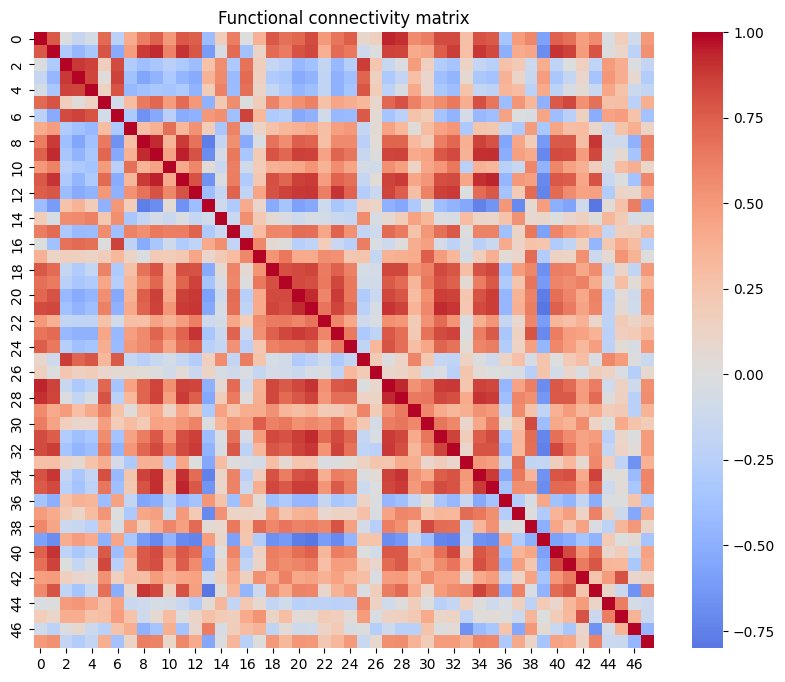

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(connectivity_matrix, cmap="coolwarm", center=0)
plt.title("Functional connectivity matrix")
plt.show()

Using an atlas-based parcellation, the fMRI scan was reduced to regional time series.

A correlation matrix was then computed to estimate functional connectivity between brain regions.

## Subject-level and average connectomes

In [31]:
records = []

for f in fmri_files:
    parts = f.replace(".nii.gz", "").split("_")
    subject = parts[0]
    session = parts[1]

    records.append({
        "subject": subject,
        "session": session,
        "filename": f
    })

fmri_df = pd.DataFrame(records)
fmri_df

,subject,session,filename
0,sub-MOA108,ses-b0,sub-MOA108_ses-b0_task-rest_run-01_bold.nii.gz
1,sub-MOA108,ses-d2,sub-MOA108_ses-d2_task-rest_run-01_bold.nii.gz
2,sub-MOA111,ses-b0,sub-MOA111_ses-b0_task-rest_run-01_bold.nii.gz
3,sub-MOA111,ses-d2,sub-MOA111_ses-d2_task-rest_run-01_bold.nii.gz
4,sub-MOA126,ses-b0,sub-MOA126_ses-b0_task-rest_run-01_bold.nii.gz
5,sub-MOA126,ses-d2,sub-MOA126_ses-d2_task-rest_run-01_bold.nii.gz


In [38]:
all_time_series = {}

for _, row in fmri_df.iterrows():
    key = f"{row['subject']}_{row['session']}"
    ts = masker.fit_transform(row["filename"])
    all_time_series[key] = ts
    print(key, ts.shape)

/tmp/ipykernel_466/762611195.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(row["filename"])
/tmp/ipykernel_466/762611195.py:5: UserWarning: Casting data from int16 to float32
  ts = masker.fit_transform(row["filename"])


sub-MOA108_ses-b0 (192, 48)


/tmp/ipykernel_466/762611195.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(row["filename"])
/tmp/ipykernel_466/762611195.py:5: UserWarning: Casting data from int16 to float32
  ts = masker.fit_transform(row["filename"])


sub-MOA108_ses-d2 (192, 48)


/tmp/ipykernel_466/762611195.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(row["filename"])
/tmp/ipykernel_466/762611195.py:5: UserWarning: Casting data from int16 to float32
  ts = masker.fit_transform(row["filename"])


...

sub-MOA111_ses-d2 (192, 48)


/tmp/ipykernel_466/762611195.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(row["filename"])
/tmp/ipykernel_466/762611195.py:5: UserWarning: Casting data from int16 to float32
  ts = masker.fit_transform(row["filename"])


sub-MOA126_ses-b0 (192, 48)


/tmp/ipykernel_466/762611195.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  ts = masker.fit_transform(row["filename"])
/tmp/ipykernel_466/762611195.py:5: UserWarning: Casting data from int16 to float32
  ts = masker.fit_transform(row["filename"])


sub-MOA126_ses-d2 (192, 48)


In [39]:
correlation_measure = ConnectivityMeasure(kind="correlation")

all_connectivity = {}

for key, ts in all_time_series.items():
    matrix = correlation_measure.fit_transform([ts])[0]
    all_connectivity[key] = matrix
    print(key, matrix.shape)

sub-MOA108_ses-b0 (48, 48)
sub-MOA108_ses-d2 (48, 48)
sub-MOA111_ses-b0 (48, 48)
sub-MOA111_ses-d2 (48, 48)
sub-MOA126_ses-b0 (48, 48)
sub-MOA126_ses-d2 (48, 48)


/tmp/ipykernel_466/2426474927.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  matrix = correlation_measure.fit_transform([ts])[0]
/tmp/ipykernel_466/2426474927.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warni

In [40]:
subject = "sub-MOA108"

b0_matrix = all_connectivity[f"{subject}_ses-b0"]
d2_matrix = all_connectivity[f"{subject}_ses-d2"]

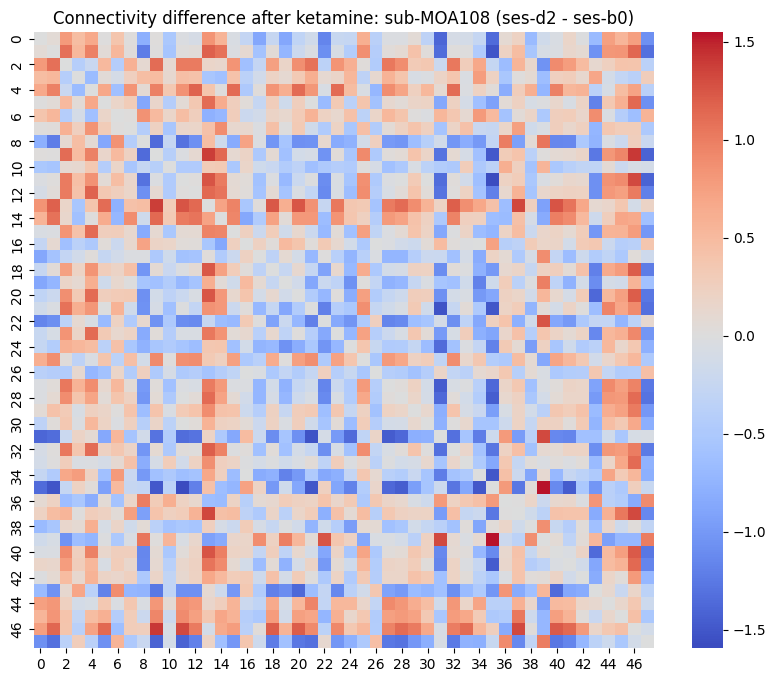

In [41]:
diff_matrix = d2_matrix - b0_matrix

plt.figure(figsize=(10, 8))
sns.heatmap(diff_matrix, cmap="coolwarm", center=0)
plt.title(f"Connectivity difference after ketamine: {subject} (ses-d2 - ses-b0)")
plt.show()

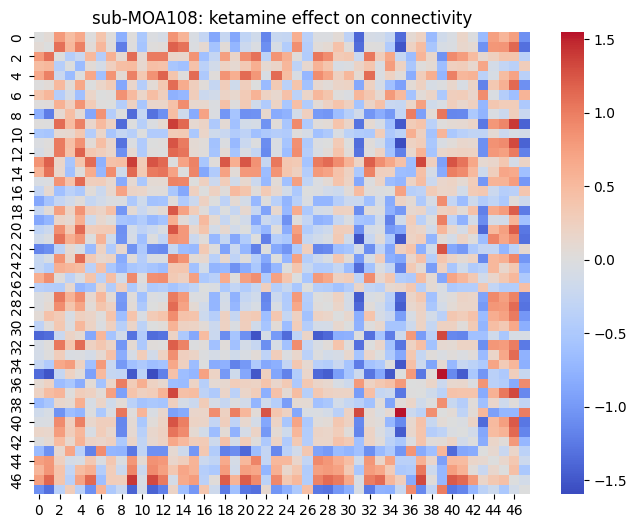

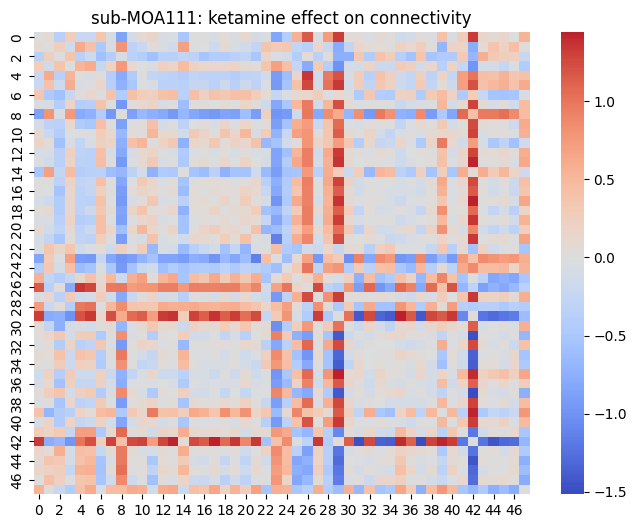

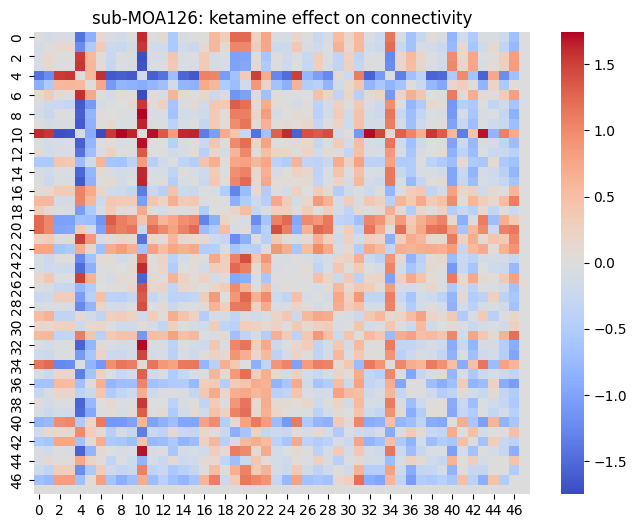

In [42]:
subjects = fmri_df["subject"].unique()

for subject in subjects:
    b0_matrix = all_connectivity[f"{subject}_ses-b0"]
    d2_matrix = all_connectivity[f"{subject}_ses-d2"]
    diff_matrix = d2_matrix - b0_matrix

    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_matrix, cmap="coolwarm", center=0)
    plt.title(f"{subject}: ketamine effect on connectivity")
    plt.show()

In [43]:
b0_matrices = []
d2_matrices = []

for subject in subjects:
    b0_matrices.append(all_connectivity[f"{subject}_ses-b0"])
    d2_matrices.append(all_connectivity[f"{subject}_ses-d2"])

mean_b0 = np.mean(b0_matrices, axis=0)
mean_d2 = np.mean(d2_matrices, axis=0)
mean_diff = mean_d2 - mean_b0

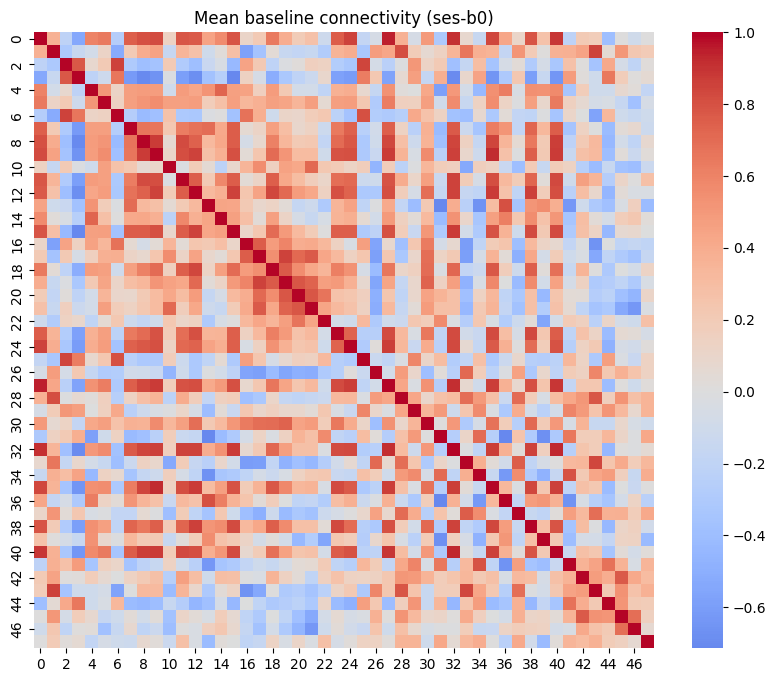

In [44]:
plt.figure(figsize=(10, 8))
sns.heatmap(mean_b0, cmap="coolwarm", center=0)
plt.title("Mean baseline connectivity (ses-b0)")
plt.show()

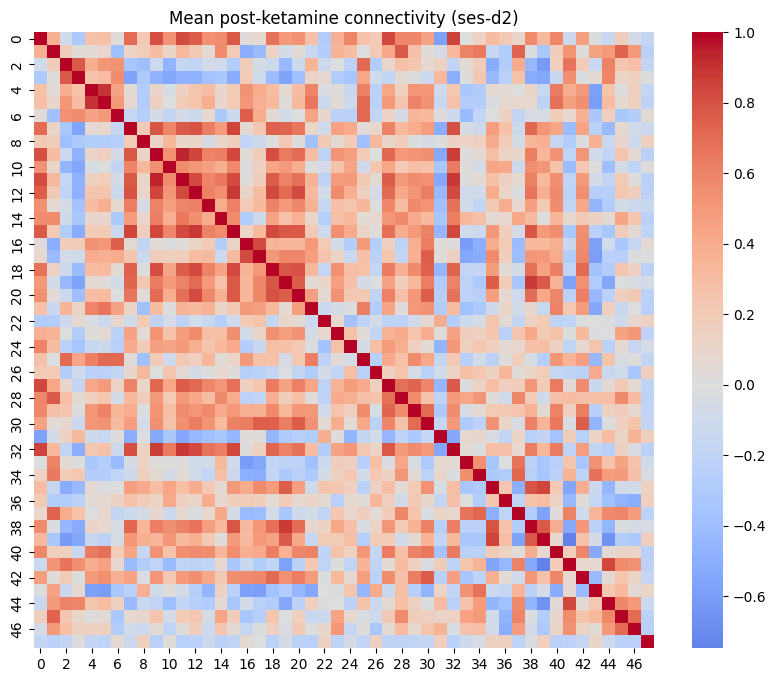

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(mean_d2, cmap="coolwarm", center=0)
plt.title("Mean post-ketamine connectivity (ses-d2)")
plt.show()

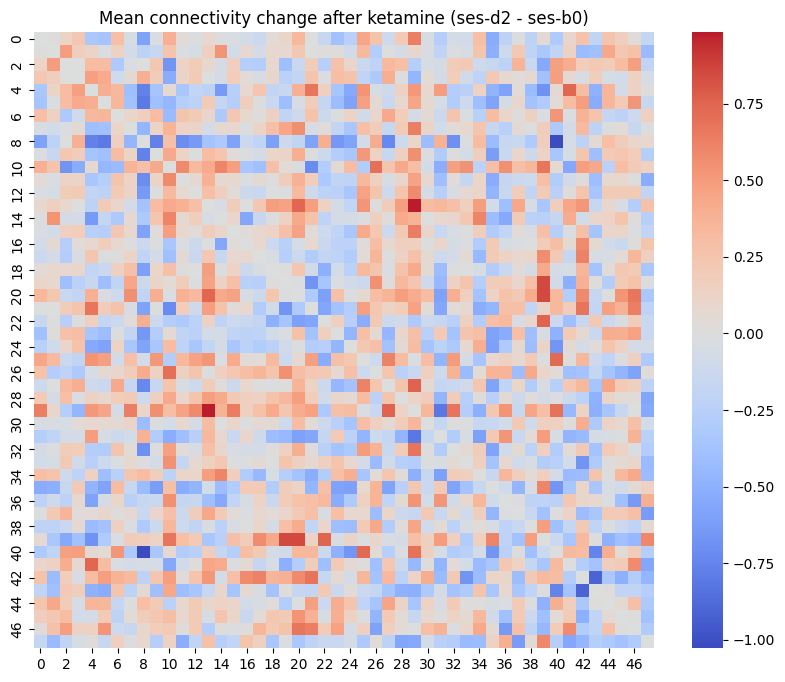

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(mean_diff, cmap="coolwarm", center=0)
plt.title("Mean connectivity change after ketamine (ses-d2 - ses-b0)")
plt.show()

Connectivity matrices were computed for each subject at baseline and after ketamine.

To estimate treatment-related effects, baseline matrices were subtracted from post-ketamine matrices.

Average matrices across participants were then used to identify group-level connectivity shifts.

## Preliminary connectome findings

In [47]:
n_regions = mean_diff.shape[0]

connections = []

for i in range(n_regions):
    for j in range(i+1, n_regions):
        connections.append({
            "region_1": i,
            "region_2": j,
            "delta_connectivity": mean_diff[i, j]
        })

connections_df = pd.DataFrame(connections)

In [53]:
connections_df.head()

,region_1,region_2,delta_connectivity
0,0,1,0.010150
1,0,2,0.119139
2,0,3,0.223392
3,0,4,-0.330490
4,0,5,-0.361385


In [55]:
top_increases = connections_df.sort_values("delta_connectivity", ascending=False).head(10)
top_increases.head()

,region_1,region_2,delta_connectivity
548,13,29,0.982926
768,20,39,0.851048
741,19,39,0.849788
919,27,29,0.757804
819,22,39,0.753948


In [56]:
top_decreases = connections_df.sort_values("delta_connectivity", ascending=True).head(10)
top_decreases.head()

,region_1,region_2,delta_connectivity
379,8,40,-1.027946
1113,42,43,-0.904076
958,29,31,-0.808873
227,5,8,-0.805455
185,4,8,-0.766696


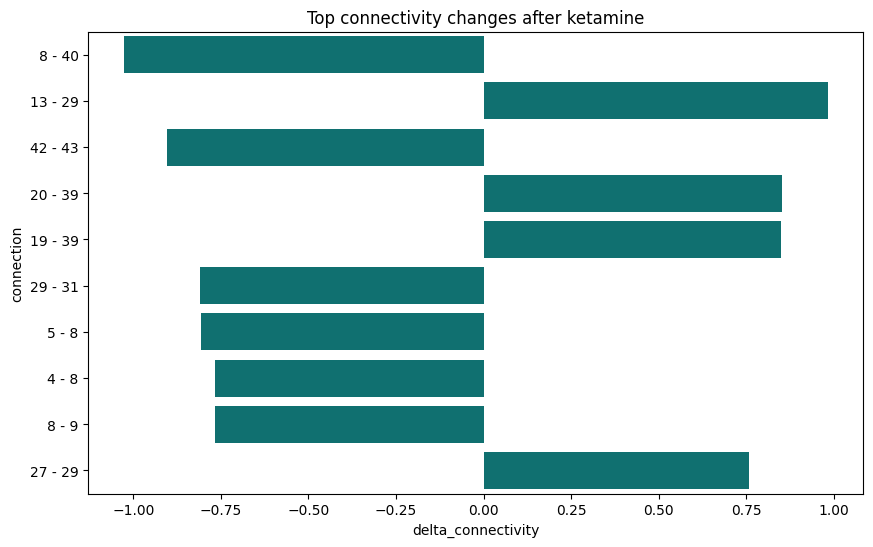

In [52]:
top_abs = connections_df.reindex(
    connections_df["delta_connectivity"].abs().sort_values(ascending=False).index
).head(10)

top_abs["connection"] = top_abs["region_1"].astype(str) + " - " + top_abs["region_2"].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_abs, x="delta_connectivity", y="connection", color='teal')
plt.title("Top connectivity changes after ketamine")
plt.show()

Connectivity differences were computed as post-ketamine minus baseline values.

Positive values indicate stronger functional coupling after ketamine,
while negative values indicate weaker connectivity.

In this small exploratory subset, ketamine-related changes were not uniform:
some region pairs showed marked increases in connectivity, while others showed decreases,
suggesting selective network reorganization rather than a global shift.

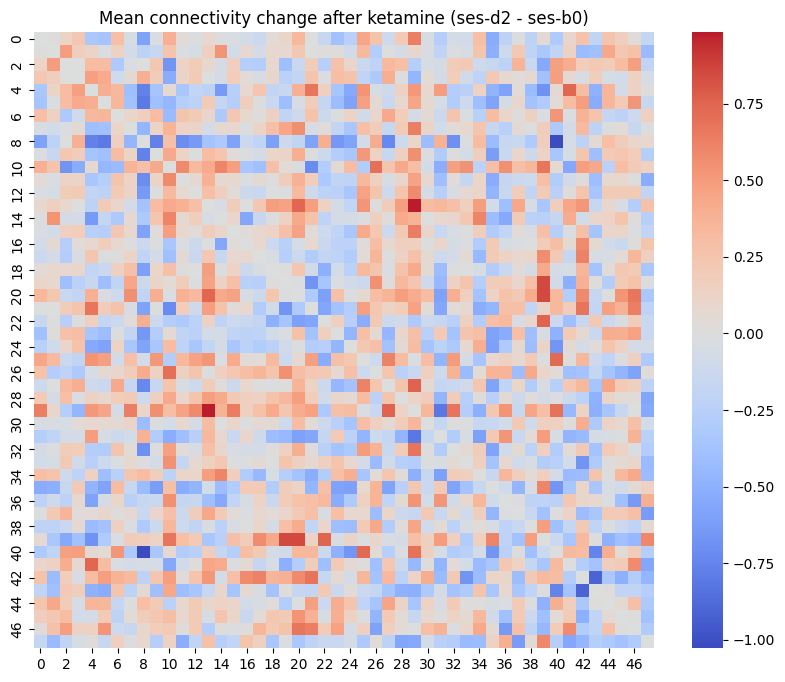

In [57]:
plt.figure(figsize=(10, 8))
sns.heatmap(mean_diff, cmap="coolwarm", center=0)
plt.title("Mean connectivity change after ketamine (ses-d2 - ses-b0)")
plt.show()

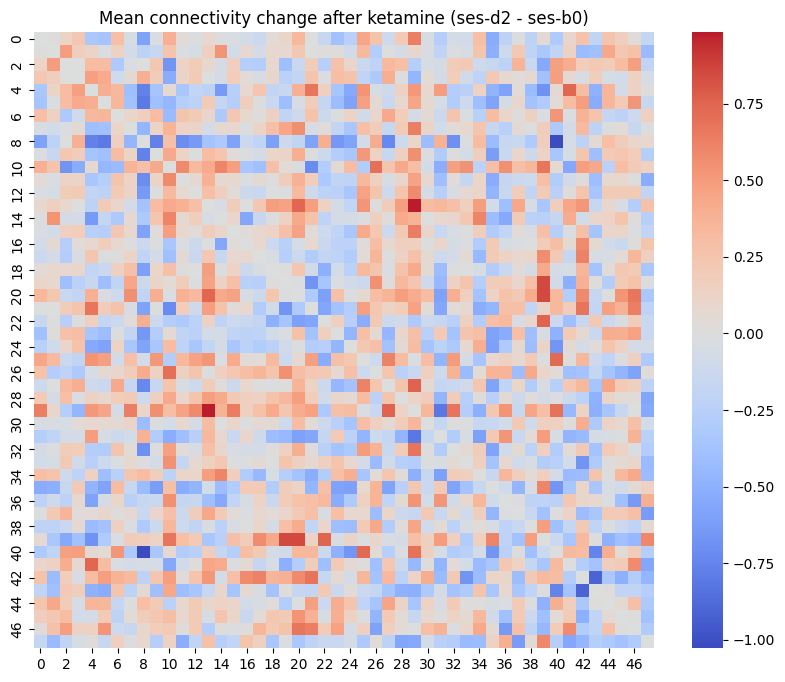

In [61]:
plt.figure(figsize=(10, 8))
sns.heatmap(mean_diff, cmap="coolwarm", center=0)
plt.title("Mean connectivity change after ketamine (ses-d2 - ses-b0)")
plt.savefig("mean_diff_heatmap.png", dpi=300, bbox_inches="tight")

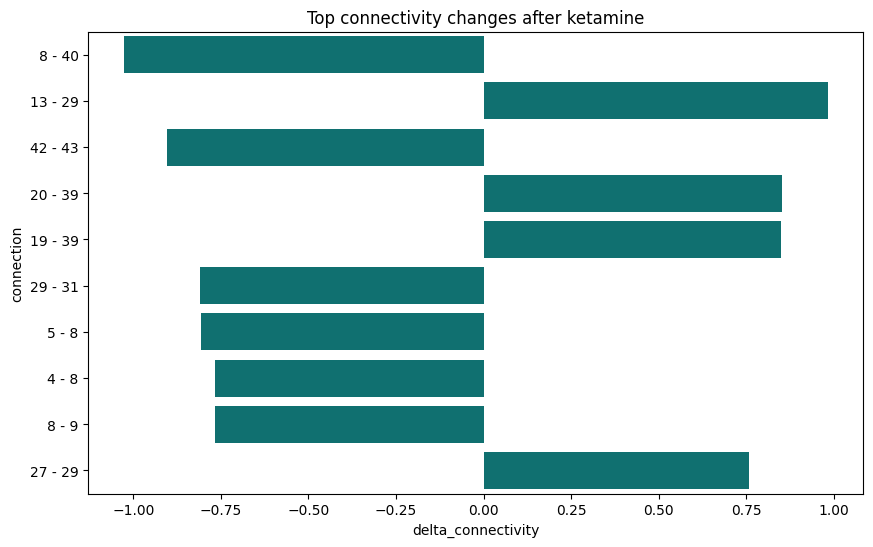

In [62]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_abs, x="delta_connectivity", y="connection", color='teal')
plt.title("Top connectivity changes after ketamine")
plt.savefig("top_connectivity_changes.png", dpi=300, bbox_inches="tight")

## Brain regions with strongest connectivity increases

In [63]:
top_abs = connections_df.reindex(
    connections_df["delta_connectivity"].abs().sort_values(ascending=False).index
).head(10)

top_abs

,region_1,region_2,delta_connectivity
379,8,40,-1.027946
548,13,29,0.982926
1113,42,43,-0.904076
768,20,39,0.851048
741,19,39,0.849788
958,29,31,-0.808873
227,5,8,-0.805455
185,4,8,-0.766696
348,8,9,-0.765838
919,27,29,0.757804


In [64]:
len(atlas_labels), atlas_labels[:10]

(49,
 ['Background',
  'Frontal Pole',
  'Insular Cortex',
  'Superior Frontal Gyrus',
  'Middle Frontal Gyrus',
  'Inferior Frontal Gyrus, pars triangularis',
  'Inferior Frontal Gyrus, pars opercularis',
  'Precentral Gyrus',
  'Temporal Pole',
  'Superior Temporal Gyrus, anterior division'])

In [65]:
for i, label in enumerate(atlas_labels):
    print(i, label)

0 Background
1 Frontal Pole
2 Insular Cortex
3 Superior Frontal Gyrus
4 Middle Frontal Gyrus
5 Inferior Frontal Gyrus, pars triangularis
6 Inferior Frontal Gyrus, pars opercularis
7 Precentral Gyrus
8 Temporal Pole
9 Superior Temporal Gyrus, anterior division
10 Superior Temporal Gyrus, posterior division
11 Middle Temporal Gyrus, anterior division
12 Middle Temporal Gyrus, posterior division
13 Middle Temporal Gyrus, temporooccipital part
14 Inferior Temporal Gyrus, anterior division
15 Inferior Temporal Gyrus, posterior division
16 Inferior Temporal Gyrus, temporooccipital part
17 Postcentral Gyrus
18 Superior Parietal Lobule
19 Supramarginal Gyrus, anterior division
20 Supramarginal Gyrus, posterior division
21 Angular Gyrus
22 Lateral Occipital Cortex, superior division
23 Lateral Occipital Cortex, inferior division
24 Intracalcarine Cortex
25 Frontal Medial Cortex
26 Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
27 Subcallosal Cortex
28 Paracingulate Gyrus
29

In [66]:
region_labels = atlas_labels[1:]

In [67]:
len(region_labels)

48

In [68]:
top_increases_named = top_increases.copy()
top_increases_named["region_1_name"] = top_increases_named["region_1"].map(lambda x: region_labels[x])
top_increases_named["region_2_name"] = top_increases_named["region_2"].map(lambda x: region_labels[x])

top_increases_named

,region_1,region_2,delta_connectivity,region_1_name,region_2_name
548,13,29,0.982926,"Inferior Temporal Gyrus, anterior division","Cingulate Gyrus, posterior division"
768,20,39,0.851048,Angular Gyrus,Occipital Fusiform Gyrus
741,19,39,0.849788,"Supramarginal Gyrus, posterior division",Occipital Fusiform Gyrus
919,27,29,0.757804,Paracingulate Gyrus,"Cingulate Gyrus, posterior division"
819,22,39,0.753948,"Lateral Occipital Cortex, inferior division",Occipital Fusiform Gyrus
539,13,20,0.744820,"Inferior Temporal Gyrus, anterior division",Angular Gyrus
218,4,41,0.744170,"Inferior Frontal Gyrus, pars triangularis",Central Opercular Cortex
889,25,40,0.737281,Juxtapositional Lobule Cortex (formerly Supple...,Frontal Opercular Cortex
440,10,26,0.699729,"Middle Temporal Gyrus, anterior division",Subcallosal Cortex
967,29,40,0.688834,"Cingulate Gyrus, posterior division",Frontal Opercular Cortex


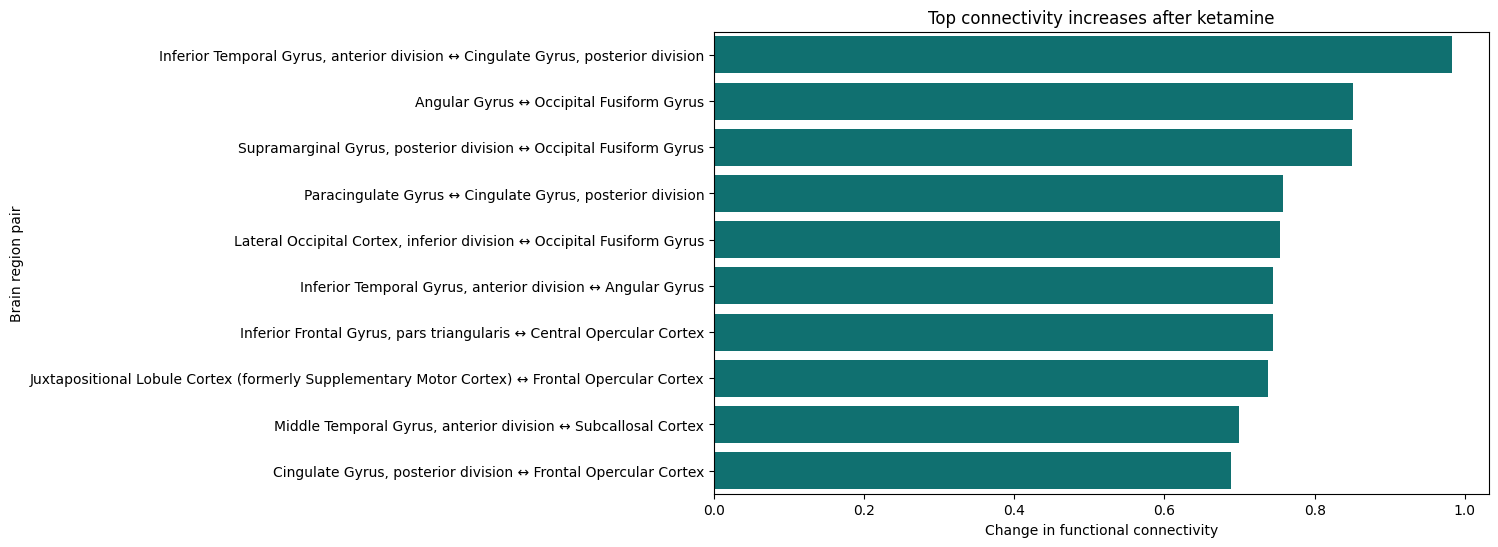

In [70]:
top_increases_named["connection"] = (
    top_increases_named["region_1_name"]
    + " ↔ "
    + top_increases_named["region_2_name"]
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_increases_named,
    x="delta_connectivity",
    y="connection",
    color='teal'
)

plt.title("Top connectivity increases after ketamine")
plt.xlabel("Change in functional connectivity")
plt.ylabel("Brain region pair")

plt.show()

Several of the strongest connectivity changes involve regions commonly
associated with large-scale brain networks implicated in depression.

Notably, multiple connections involve:

- Posterior Cingulate Cortex
- Paracingulate Cortex
- Angular Gyrus
- Supramarginal Gyrus

These regions are part of the **Default Mode Network (DMN)** and adjacent
association cortices.

Previous neuroimaging studies suggest that ketamine may alter large-scale
network interactions related to self-referential processing and emotional
regulation.

## Summary

In this notebook, resting-state fMRI scans were transformed into regional
time series using the Harvard-Oxford atlas.

Functional connectivity matrices were computed for baseline and post-ketamine
sessions.

Connectivity differences revealed selective increases in coupling between
temporal, parietal, and cingulate regions.

Several of these regions are associated with the Default Mode Network,
which has been previously implicated in depression and ketamine response.